# 📉 Customer Churn Prediction — XGBoost + SHAP
**Dataset:** Telco Customer Churn (Kaggle)  
**Author:** Sandeep Kumar | LPU  
**Purpose:** ShyftLabs Placement Portfolio — Data Science Track

---
## Notebook Structure
1. Setup & Feature Engineering
2. Train/Test Split + SMOTE
3. XGBoost Model Training
4. Model Evaluation
5. SHAP Explainability
6. Model Serialisation

## Section 1 — Setup & Feature Engineering

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap imbalanced-learn --quiet
print('✅ Packages ready')

✅ Packages ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys, os

sys.path.append('../src')
from features import build_features, get_feature_columns

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import shap
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706']
print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
# Load raw data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Apply feature engineering
df = build_features(df)

print(f'Shape after feature engineering: {df.shape}')
df.head(3)

Shape after feature engineering: (7043, 35)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV_flag,StreamingMovies_flag,service_count,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,No,Yes,No,...,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,Yes,No,Yes,...,0,0,2,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,Yes,Yes,No,...,0,0,2,0,0,0,0,0,0,1


In [4]:
# Get feature columns and target
feature_cols = get_feature_columns()
X = df[feature_cols]
y = df['Churn_binary']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Churn %  : {y.mean()*100:.1f}%')

Features : 27
Samples  : 7043
Churn %  : 26.5%


## Section 2 — Train/Test Split + SMOTE

In [5]:
# Stratified split — preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test size  : {X_test.shape[0]}  | Churn rate: {y_test.mean()*100:.1f}%')

Train size : 5634 | Churn rate: 26.5%
Test size  : 1409  | Churn rate: 26.5%


In [6]:
# SMOTE — Synthetic Minority Oversampling Technique
# Applied ONLY on training data to avoid data leakage
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After SMOTE : {dict(pd.Series(y_train_sm).value_counts())}')
print('→ Classes balanced for training')

Before SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
After SMOTE : {0: np.int64(4139), 1: np.int64(4139)}
→ Classes balanced for training


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

## Section 3 — XGBoost Model Training

In [7]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('\n✅ XGBoost model trained')

[0]	validation_0-logloss:0.67579
[50]	validation_0-logloss:0.47340
[100]	validation_0-logloss:0.45938
[150]	validation_0-logloss:0.45461
[200]	validation_0-logloss:0.45356
[250]	validation_0-logloss:0.45254
[299]	validation_0-logloss:0.45348

✅ XGBoost model trained


In [8]:
# Cross-validation on SMOTE data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC: 0.9263 ± 0.0043


## Section 4 — Model Evaluation

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {roc_auc:.4f}')

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
     Churned       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC Score: 0.8317


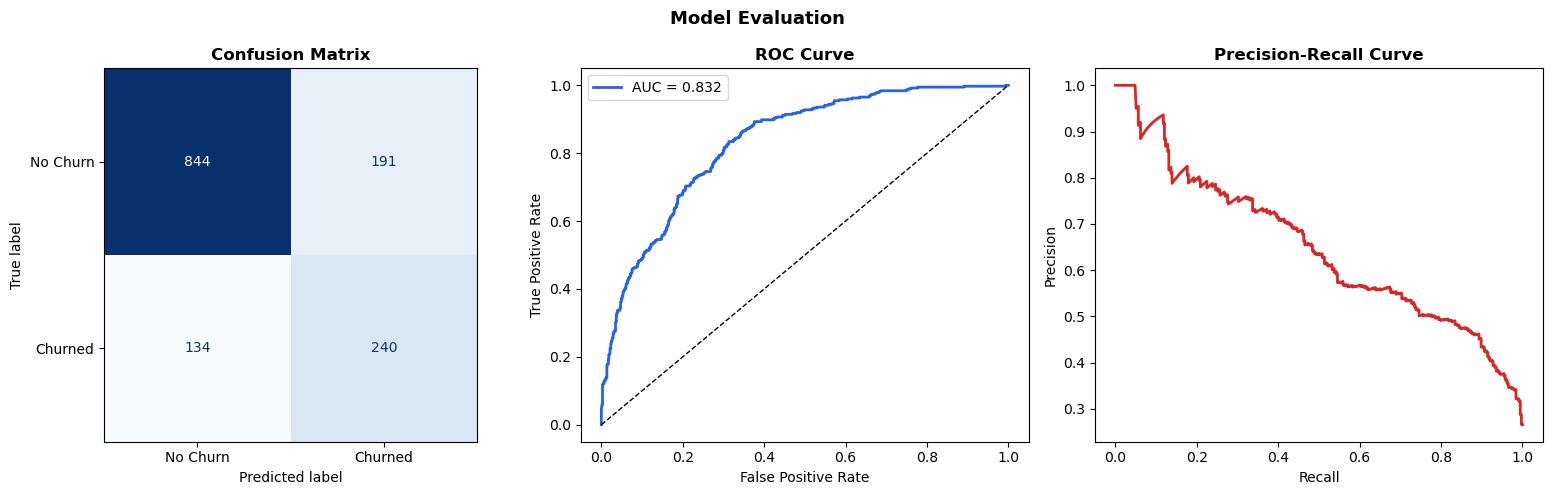

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall, precision, color=PALETTE[1], linewidth=2)
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — SHAP Explainability

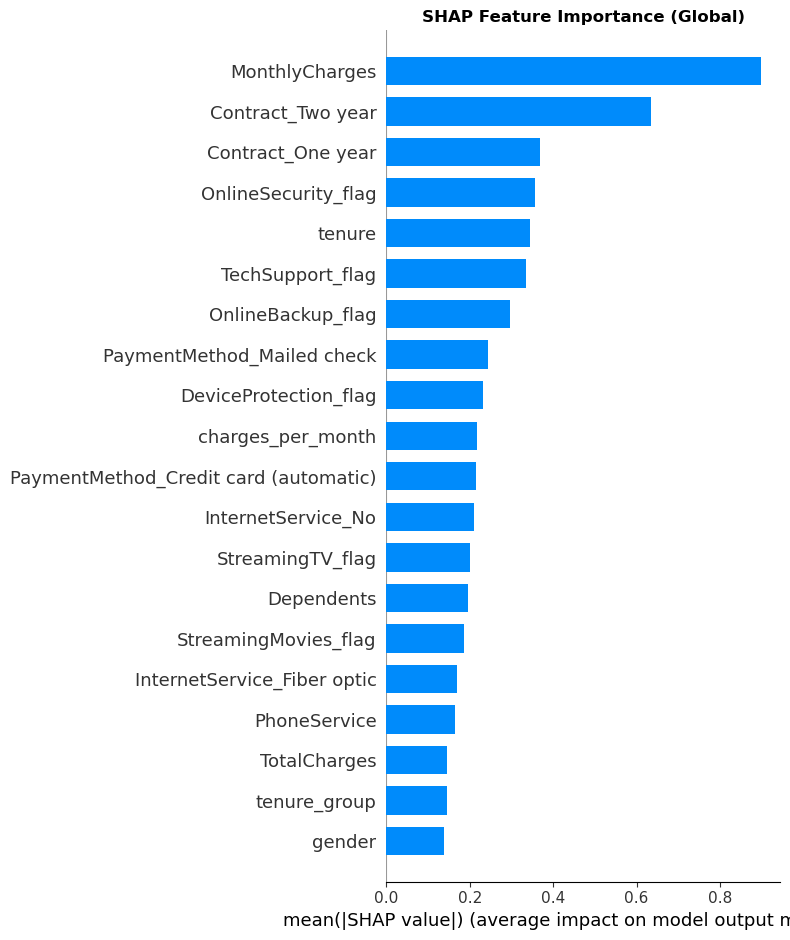

In [11]:
# SHAP values — explains individual predictions
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance (SHAP)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

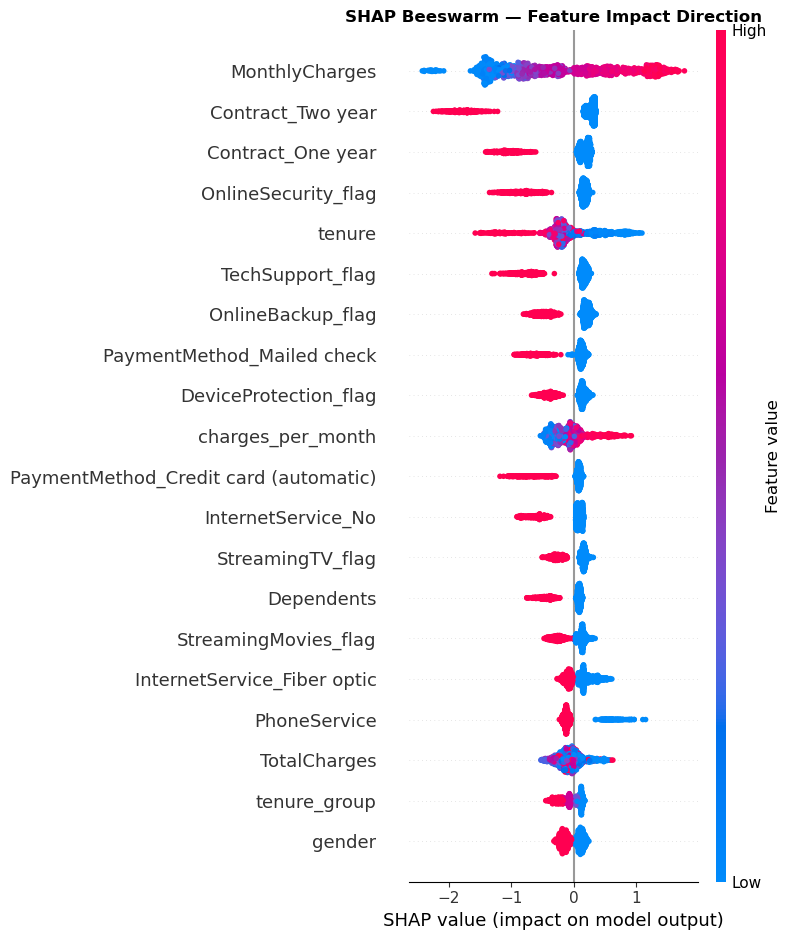

In [12]:
# SHAP beeswarm — shows direction of impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

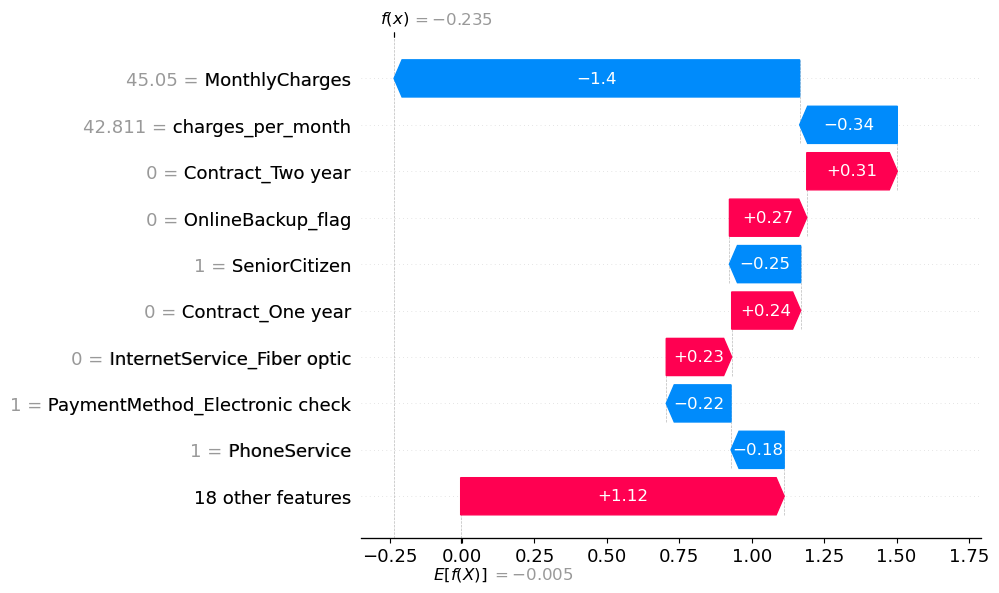

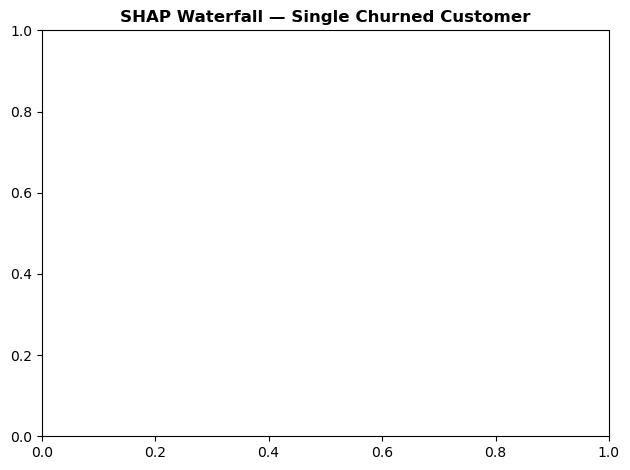

In [13]:
# SHAP waterfall — explain a single prediction (first churned customer)
churned_idx = np.where(y_test.values == 1)[0][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churned_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[churned_idx],
        feature_names=feature_cols
    )
)
plt.title('SHAP Waterfall — Single Churned Customer', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Model Serialisation

In [14]:
import json
os.makedirs('../model', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save model
joblib.dump(model, '../model/churn_model.pkl')

# Save feature column list for API
with open('../model/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

# Save test predictions for dashboard
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred
results['churn_probability'] = y_prob
results.to_csv('../data/processed/test_predictions.csv', index=False)

print('✅ Model saved       → model/churn_model.pkl')
print('✅ Features saved    → model/feature_columns.json')
print('✅ Predictions saved → data/processed/test_predictions.csv')

print(f"""
╔══════════════════════════════════════════════════════╗
║         FINAL MODEL RESULTS — CHURN PREDICTION       ║
╠══════════════════════════════════════════════════════╣
║  Model          : XGBoost (n=300, depth=4)           ║
║  ROC-AUC        : {roc_auc:.4f}                          ║
║  5-Fold CV AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}         ║
║  Imbalance fix  : SMOTE (train only)                 ║
║  Explainability : SHAP TreeExplainer                 ║
╚══════════════════════════════════════════════════════╝
""")

✅ Model saved       → model/churn_model.pkl
✅ Features saved    → model/feature_columns.json
✅ Predictions saved → data/processed/test_predictions.csv

╔══════════════════════════════════════════════════════╗
║         FINAL MODEL RESULTS — CHURN PREDICTION       ║
╠══════════════════════════════════════════════════════╣
║  Model          : XGBoost (n=300, depth=4)           ║
║  ROC-AUC        : 0.8317                          ║
║  5-Fold CV AUC  : 0.9263 ± 0.0043         ║
║  Imbalance fix  : SMOTE (train only)                 ║
║  Explainability : SHAP TreeExplainer                 ║
╚══════════════════════════════════════════════════════╝

